#LIBRARIES


#### 1. Environment Setup & Package Installation
Install required dependencies for data processing, image manipulation, and deep learning framework operations.

In [1]:
pip install pandas numpy opencv-python pillow matplotlib seaborn scikit-learn tqdm


Note: you may need to restart the kernel to use updated packages.


#### 2. Import Libraries & Configure Environment
Import necessary Python packages for data manipulation, computer vision, data visualization, and model development.

In [2]:
import os

print(os.listdir("/kaggle/input"))


['datasets']


In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/GroundTruth.csv
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0027799.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classif

In [4]:
for dirname, dirs, files in os.walk("/kaggle/input"):
    print("\nFolder:", dirname)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])



Folder: /kaggle/input
Subfolders: ['datasets']
Files: []

Folder: /kaggle/input/datasets
Subfolders: ['surajghuwalewala']
Files: []

Folder: /kaggle/input/datasets/surajghuwalewala
Subfolders: ['ham1000-segmentation-and-classification']
Files: []

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
Subfolders: ['images', 'masks']
Files: ['GroundTruth.csv']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images
Subfolders: []
Files: ['ISIC_0030912.jpg', 'ISIC_0028933.jpg', 'ISIC_0030585.jpg', 'ISIC_0028394.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks
Subfolders: []
Files: ['ISIC_0033034_segmentation.png', 'ISIC_0026058_segmentation.png', 'ISIC_0031698_segmentation.png', 'ISIC_0032330_segmentation.png', 'ISIC_0030246_segmentation.png', 'I

In [5]:
from pathlib import Path
import pandas as pd
# Define paths based on Kaggle input directory
DATA_ROOT = Path(
    "/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification"
)

print("Dataset exists:", DATA_ROOT.exists())
print("Dataset path:", DATA_ROOT)


Dataset exists: True
Dataset path: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification


## Exploratory Data Analysis (EDA)
Load the ground truth labels and inspect the class distribution, missing values, and dataset size.

In [6]:
# Load dataset metadata
metadata_path = DATA_ROOT / "GroundTruth.csv"

df = pd.read_csv(metadata_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# print("\nFirst 5 rows:")
# display(df.head())


Shape: (10015, 8)

Columns:
['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [7]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  object 
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), object(1)
memory usage: 626.1+ KB
None


In [8]:
print(df.head(10))


          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
5  ISIC_0024311  0.0  1.0  0.0    0.0  0.0  0.0   0.0
6  ISIC_0024312  0.0  0.0  0.0    0.0  1.0  0.0   0.0
7  ISIC_0024313  1.0  0.0  0.0    0.0  0.0  0.0   0.0
8  ISIC_0024314  0.0  1.0  0.0    0.0  0.0  0.0   0.0
9  ISIC_0024315  1.0  0.0  0.0    0.0  0.0  0.0   0.0


In [9]:
for root, dirs, files in os.walk(DATA_ROOT):
    print("\nFolder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])


Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
Subfolders: ['images', 'masks']
Files: ['GroundTruth.csv']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images
Subfolders: []
Files: ['ISIC_0030912.jpg', 'ISIC_0028933.jpg', 'ISIC_0030585.jpg', 'ISIC_0028394.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks
Subfolders: []
Files: ['ISIC_0033034_segmentation.png', 'ISIC_0026058_segmentation.png', 'ISIC_0031698_segmentation.png', 'ISIC_0032330_segmentation.png', 'ISIC_0030246_segmentation.png', 'ISIC_0026281_segmentation.png', 'ISIC_0024577_segmentation.png', 'ISIC_0024910_segmentation.png', 'ISIC_0031771_segmentation.png', 'ISIC_0029679_segmentation.png']


In [10]:
label_columns = df.columns[1:].tolist()


print("Label columns:", label_columns)

Label columns: ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [11]:
# Check each class
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

for col in classes:
    print(f"{col}: {df[col].sum()}")


MEL: 1113.0
NV: 6705.0
BCC: 514.0
AKIEC: 327.0
BKL: 1099.0
DF: 115.0
VASC: 142.0


In [12]:
# ============================================================
# LABEL PREPROCESSING
# ============================================================

# HAM10000 classes present in GroundTruth.csv
classes = [
    "MEL",
    "NV",
    "BCC",
    "AKIEC",
    "BKL",
    "DF",
    "VASC"
]

# Check that all expected label columns exist
missing_classes = [c for c in classes if c not in df.columns]

if missing_classes:
    raise ValueError(
        f"Missing label columns in GroundTruth.csv: {missing_classes}"
    )

# Make sure label columns are numeric
df[classes] = df[classes].apply(
    pd.to_numeric,
    errors="coerce"
)

# Check for invalid/missing label values
print("Missing values in label columns:")
print(df[classes].isna().sum())

# Fill missing label values with 0
df[classes] = df[classes].fillna(0)

# Check that every image has exactly one class
df["label_sum"] = df[classes].sum(axis=1)

print("\nLabel sum distribution:")
print(df["label_sum"].value_counts())

# Keep only rows having exactly one positive class
df = df[df["label_sum"] == 1].copy()

# Convert one-hot encoded labels into class name
df["label"] = df[classes].idxmax(axis=1)

# Convert class name to numerical ID
from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# assign numerical labels
df["label_id"] = label_encoder.fit_transform(df["label"])

#  create mappings
label_map = {
    label: int(label_id)
    for label, label_id in zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
}

# Reverse mapping – useful later during prediction
id_to_label = {
    v: k for k, v in label_map.items()
}

print("\nClass mapping:")
for class_name, class_id in label_map.items():
    print(f"{class_id} -> {class_name}")

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nFirst 10 records:")
display(
    df[["image", "label", "label_id"]].head(10)
)

Missing values in label columns:
MEL      0
NV       0
BCC      0
AKIEC    0
BKL      0
DF       0
VASC     0
dtype: int64

Label sum distribution:
label_sum
1.0    10015
Name: count, dtype: int64

Class mapping:
0 -> AKIEC
1 -> BCC
2 -> BKL
3 -> DF
4 -> MEL
5 -> NV
6 -> VASC

Class distribution:
label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64

First 10 records:


,image,label,label_id
0,ISIC_0024306,NV,5
1,ISIC_0024307,NV,5
2,ISIC_0024308,NV,5
3,ISIC_0024309,NV,5
4,ISIC_0024310,MEL,4
5,ISIC_0024311,NV,5
6,ISIC_0024312,BKL,2
7,ISIC_0024313,MEL,4
8,ISIC_0024314,NV,5
9,ISIC_0024315,MEL,4


In [13]:
#Check the image files
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png"}

image_files = []

for path in DATA_ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in image_extensions:
        image_files.append(path)

print("Total image files found:", len(image_files))

print("\nFirst 20 images:")
for path in image_files[:20]:
    print(path)


Total image files found: 20030

First 20 images:
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0027799.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028100.jpg
/kaggle/input/d

In [14]:
mask_files = []

for path in DATA_ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in image_extensions:
        if "mask" in str(path).lower() or "segment" in str(path).lower():
            mask_files.append(path)

print("Possible mask files:", len(mask_files))

for path in mask_files[:20]:
    print(path)


Possible mask files: 20030
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0027799.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028100.jpg
/kaggle/input/datasets/surajghuwalewa

In [15]:
#Check the image names against the CSV
print("CSV image examples:")
print(df["image"].head(10).tolist())


CSV image examples:
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']


In [16]:
print("\nActual image examples:")

for path in image_files[:10]:
    print(path.name)



Actual image examples:
ISIC_0030912.jpg
ISIC_0028933.jpg
ISIC_0030585.jpg
ISIC_0028394.jpg
ISIC_0033697.jpg
ISIC_0030062.jpg
ISIC_0031213.jpg
ISIC_0027799.jpg
ISIC_0028100.jpg
ISIC_0027960.jpg


In [17]:
image_path_dict = {
    path.stem: str(path)
    for path in image_files
}

df["image_path"] = df["image"].map(image_path_dict)

print(df[["image", "image_path"]].head(10))


          image                                         image_path
0  ISIC_0024306  /kaggle/input/datasets/surajghuwalewala/ham100...
1  ISIC_0024307  /kaggle/input/datasets/surajghuwalewala/ham100...
2  ISIC_0024308  /kaggle/input/datasets/surajghuwalewala/ham100...
3  ISIC_0024309  /kaggle/input/datasets/surajghuwalewala/ham100...
4  ISIC_0024310  /kaggle/input/datasets/surajghuwalewala/ham100...
5  ISIC_0024311  /kaggle/input/datasets/surajghuwalewala/ham100...
6  ISIC_0024312  /kaggle/input/datasets/surajghuwalewala/ham100...
7  ISIC_0024313  /kaggle/input/datasets/surajghuwalewala/ham100...
8  ISIC_0024314  /kaggle/input/datasets/surajghuwalewala/ham100...
9  ISIC_0024315  /kaggle/input/datasets/surajghuwalewala/ham100...


In [18]:
print(
    "Images found:",
    df["image_path"].notna().sum()
)

print(
    "Images missing:",
    df["image_path"].isna().sum()
)


Images found: 10015
Images missing: 0


In [19]:
#Remove invalid records
df = df.dropna(
    subset=["image_path"]
).copy()

print("Remaining images:", len(df))


Remaining images: 10015


In [20]:
#Check for corrupted images
from PIL import Image
from tqdm import tqdm

bad_images = []

for path in tqdm(
    df["image_path"],
    desc="Checking images"
):
    try:
        with Image.open(path) as img:
            img.verify()

    except Exception:
        bad_images.append(path)

print("Corrupted images:", len(bad_images))


Checking images: 100%|██████████| 10015/10015 [01:15<00:00, 132.50it/s]

Corrupted images: 0


In [21]:
#Check image dimensions
from collections import Counter

sizes = []

for path in tqdm(
    df["image_path"],
    desc="Checking dimensions"
):

    with Image.open(path) as img:
        sizes.append(img.size)

print("Most common image sizes:")

for size, count in Counter(sizes).most_common(10):
    print(size, ":", count)


Checking dimensions: 100%|██████████| 10015/10015 [00:08<00:00, 1203.33it/s]

Most common image sizes:
(600, 450) : 10015


# Image Visualization
Display sample images from the dataset along with their corresponding ground truth annotations.

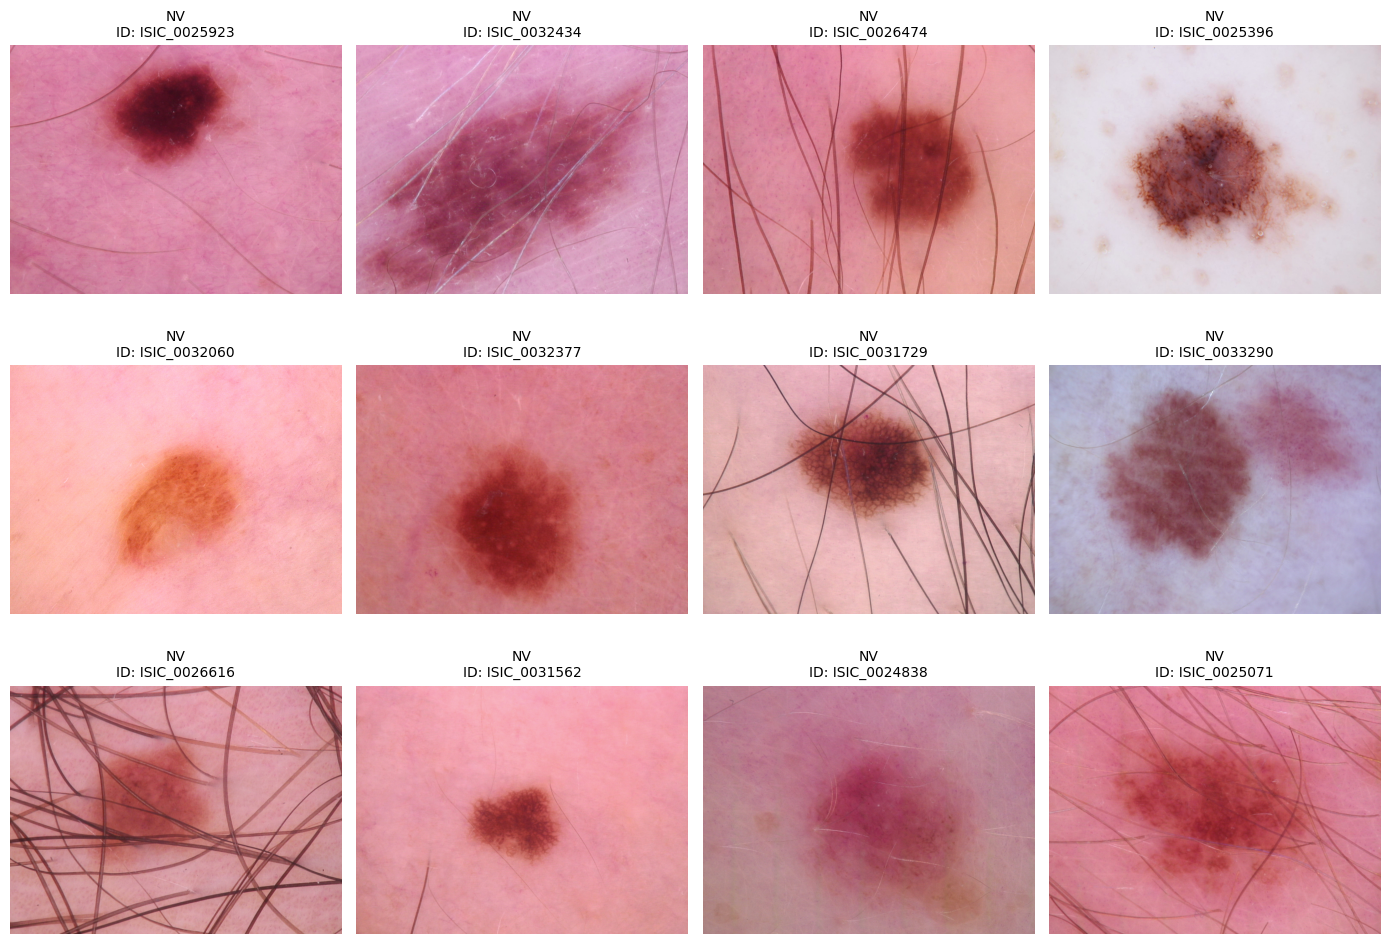

In [22]:
#Visualize some images
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.sample(
    12,
    random_state=42
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 10)
)

for ax, (_, row) in zip(
    axes.flatten(),
    sample_df.iterrows()
):

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        f"{row['label']}\nID: {row['image']}",
        fontsize=10
    )

    ax.axis("off")

plt.tight_layout()
plt.show()


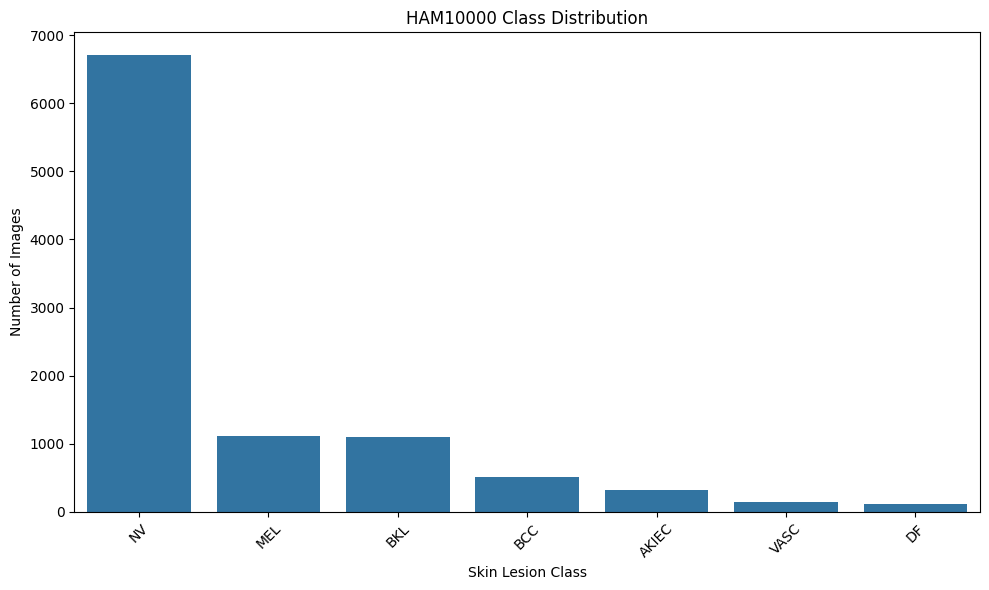

In [23]:
#Check class distribution visually
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.title(
    "HAM10000 Class Distribution"
)

plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [24]:
#display percentages
class_distribution = df["label"].value_counts()

class_percentage = (
    df["label"].value_counts(normalize=True) * 100
).round(2)

distribution_table = pd.DataFrame({
    "Count": class_distribution,
    "Percentage": class_percentage
})

display(distribution_table)

,Count,Percentage
label,,
NV,6705,66.95
MEL,1113,11.11
BKL,1099,10.97
BCC,514,5.13
AKIEC,327,3.27
VASC,142,1.42
DF,115,1.15


In [25]:
#Save our cleaned metadata
from pathlib import Path

PROCESSED_DIR = Path("/kaggle/working/skinova_processed")

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [26]:
df.to_csv(
    PROCESSED_DIR / "cleaned_metadata.csv",
    index=False
)

print(
    "Saved to:",
    PROCESSED_DIR / "cleaned_metadata.csv"
)


Saved to: /kaggle/working/skinova_processed/cleaned_metadata.csv


In [27]:
print("Number of CSV rows:", len(df))

print("\nCSV image names:")
print(df["image"].head(10).tolist())

print("\nNumber of image files found:", len(image_files))

print("\nActual image files:")
for path in image_files[:20]:
    print(path)

print("\nNumber of mask files found:", len(mask_files))

print("\nActual mask files:")
for path in mask_files[:20]:
    print(path)


Number of CSV rows: 10015

CSV image names:
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']

Number of image files found: 20030

Actual image files:
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/in

In [28]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# First split:
# 80% training
# 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_id"],
    random_state=42
)

# Second split:
# 10% validation
# 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples  :", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples   :", len(test_df))

Training samples  : 8012
Validation samples: 1001
Testing samples   : 1002


In [29]:
print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())


Training distribution:
label
NV       5364
MEL       890
BKL       879
BCC       411
AKIEC     262
VASC      114
DF         92
Name: count, dtype: int64

Validation distribution:
label
NV       670
MEL      111
BKL      110
BCC       51
AKIEC     33
VASC      14
DF        12
Name: count, dtype: int64

Test distribution:
label
NV       671
MEL      112
BKL      110
BCC       52
AKIEC     32
VASC      14
DF        11
Name: count, dtype: int64


# Data Augmentation

In [30]:
!pip install -q albumentations


In [31]:
import os
import cv2
import numpy as np
import pandas as pd
import albumentations as A
from pathlib import Path
from tqdm import tqdm

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [32]:
# ============================================================
# AUGMENTATION PIPELINE
# ============================================================

augmentation_pipeline = A.Compose([
    
    # Geometric transformations
    A.HorizontalFlip(p=0.5),
    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),
    
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=0,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.4
    ),
    
    # Mild color/intensity transformations
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
    
    # Slight image quality variation
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.15
    )
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [33]:
# ============================================================
# CREATE AUGMENTED DATASET DIRECTORY
# ============================================================

AUGMENTED_DIR = Path("/kaggle/working/skinova_augmented")

TRAIN_AUG_DIR = AUGMENTED_DIR / "train"

TRAIN_AUG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Augmented dataset directory:")
print(TRAIN_AUG_DIR)

Augmented dataset directory:
/kaggle/working/skinova_augmented/train


In [34]:
# ============================================================
# TRAINING CLASS DISTRIBUTION BEFORE AUGMENTATION
# ============================================================

train_distribution = train_df["label"].value_counts().sort_index()

print("Training distribution BEFORE augmentation:")
print(train_distribution)

Training distribution BEFORE augmentation:
label
AKIEC     262
BCC       411
BKL       879
DF         92
MEL       890
NV       5364
VASC      114
Name: count, dtype: int64


In [35]:
# ============================================================
# AUGMENTATION TARGET
# ============================================================

TARGET_IMAGES_PER_CLASS = 2000

print(
    "Target images per minority class:",
    TARGET_IMAGES_PER_CLASS
)

Target images per minority class: 2000


In [36]:
# ============================================================
# GENERATE AUGMENTED TRAINING IMAGES
# ============================================================

augmented_records = []

# Keep track of the original training images
for _, row in train_df.iterrows():
    
    augmented_records.append({
        "image": row["image"],
        "image_path": row["image_path"],
        "label": row["label"],
        "label_id": row["label_id"],
        "is_augmented": 0
    })


# Process each class separately
for class_name in train_df["label"].unique():
    
    class_df = train_df[
        train_df["label"] == class_name
    ].copy()
    
    current_count = len(class_df)
    
    # Number of additional images required
    images_to_generate = max(
        0,
        TARGET_IMAGES_PER_CLASS - current_count
    )
    
    print(
        f"\nClass: {class_name}"
    )
    print(
        f"Original images: {current_count}"
    )
    print(
        f"Augmented images required: {images_to_generate}"
    )
    
    if images_to_generate == 0:
        continue
    
    # Generate augmented images
    for i in tqdm(
        range(images_to_generate),
        desc=f"Augmenting {class_name}"
    ):
        
        # Randomly select an original image from this class
        row = class_df.sample(
            n=1,
            random_state=42 + i
        ).iloc[0]
        
        image_path = row["image_path"]
        
        # Read image
        image = cv2.imread(image_path)
        
        if image is None:
            print(
                f"Warning: Could not read {image_path}"
            )
            continue
        
        # Convert BGR -> RGB
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
        
        # Apply augmentation
        augmented = augmentation_pipeline(
            image=image
        )
        
        augmented_image = augmented["image"]
        
        # Convert RGB -> BGR for saving
        augmented_image = cv2.cvtColor(
            augmented_image,
            cv2.COLOR_RGB2BGR
        )
        
        # Create unique filename
        original_name = Path(
            row["image_path"]
        ).stem
        
        new_filename = (
            f"{original_name}_aug_{i:05d}.jpg"
        )
        
        output_path = (
            TRAIN_AUG_DIR /
            new_filename
        )
        
        # Save augmented image
        cv2.imwrite(
            str(output_path),
            augmented_image,
            [cv2.IMWRITE_JPEG_QUALITY, 95]
        )
        
        # Store metadata
        augmented_records.append({
            "image": new_filename,
            "image_path": str(output_path),
            "label": row["label"],
            "label_id": row["label_id"],
            "is_augmented": 1
        })

print("\nData augmentation completed.")


Class: NV
Original images: 5364
Augmented images required: 0

Class: AKIEC
Original images: 262
Augmented images required: 1738


Augmenting AKIEC: 100%|██████████| 1738/1738 [00:22<00:00, 77.21it/s]



Class: BKL
Original images: 879
Augmented images required: 1121


Augmenting BKL: 100%|██████████| 1121/1121 [00:14<00:00, 75.29it/s]



Class: BCC
Original images: 411
Augmented images required: 1589


...


Class: VASC
Original images: 114
Augmented images required: 1886


Augmenting VASC: 100%|██████████| 1886/1886 [00:25<00:00, 74.83it/s]



Class: DF
Original images: 92
Augmented images required: 1908


Augmenting DF: 100%|██████████| 1908/1908 [00:26<00:00, 72.62it/s]


Data augmentation completed.


In [37]:
# ============================================================
# CREATE AUGMENTED TRAINING METADATA
# ============================================================

augmented_train_df = pd.DataFrame(
    augmented_records
)

print(
    "Total training images after augmentation:",
    len(augmented_train_df)
)

print("\nClass distribution AFTER augmentation:")
print(
    augmented_train_df["label"].value_counts()
)

Total training images after augmentation: 17364

Class distribution AFTER augmentation:
label
NV       5364
AKIEC    2000
BKL      2000
BCC      2000
MEL      2000
VASC     2000
DF       2000
Name: count, dtype: int64


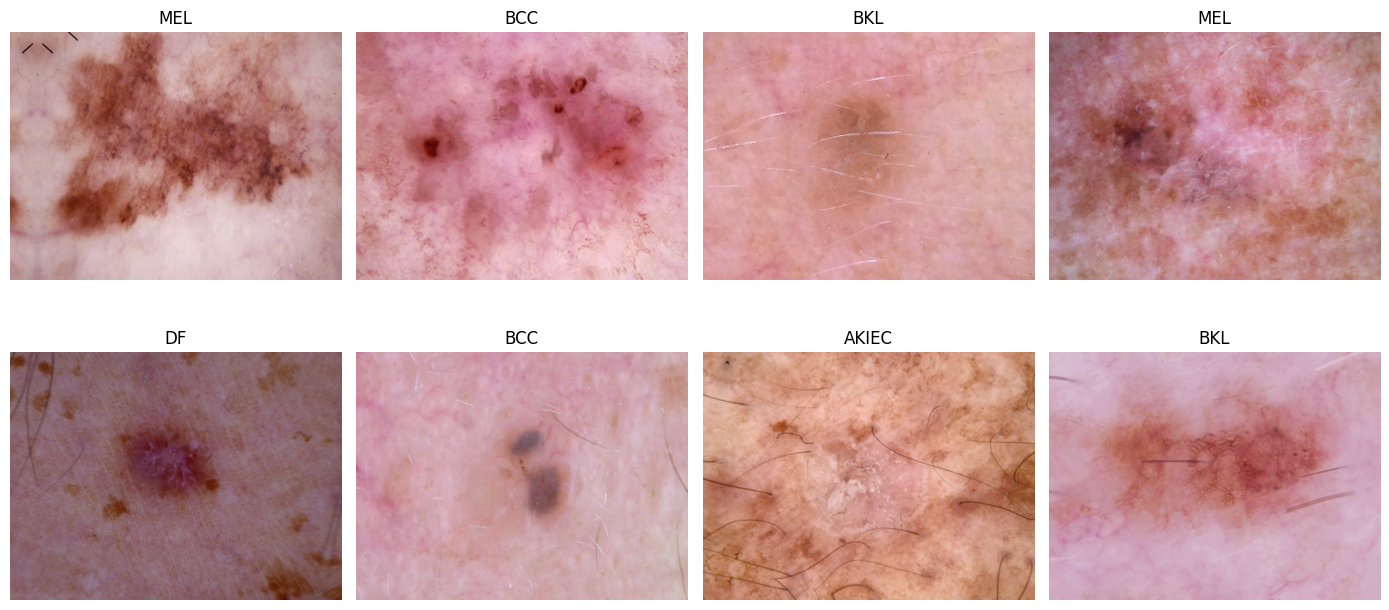

In [38]:
# ============================================================
# VISUALIZE AUGMENTED IMAGES
# ============================================================

import matplotlib.pyplot as plt

# Select augmented images only
sample_aug = augmented_train_df[
    augmented_train_df["is_augmented"] == 1
].sample(
    8,
    random_state=42
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)

for ax, (_, row) in zip(
    axes.flatten(),
    sample_aug.iterrows()
):
    
    image = cv2.imread(
        row["image_path"]
    )
    
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
    
    ax.imshow(image)
    
    ax.set_title(
        row["label"]
    )
    
    ax.axis("off")

plt.tight_layout()
plt.show()

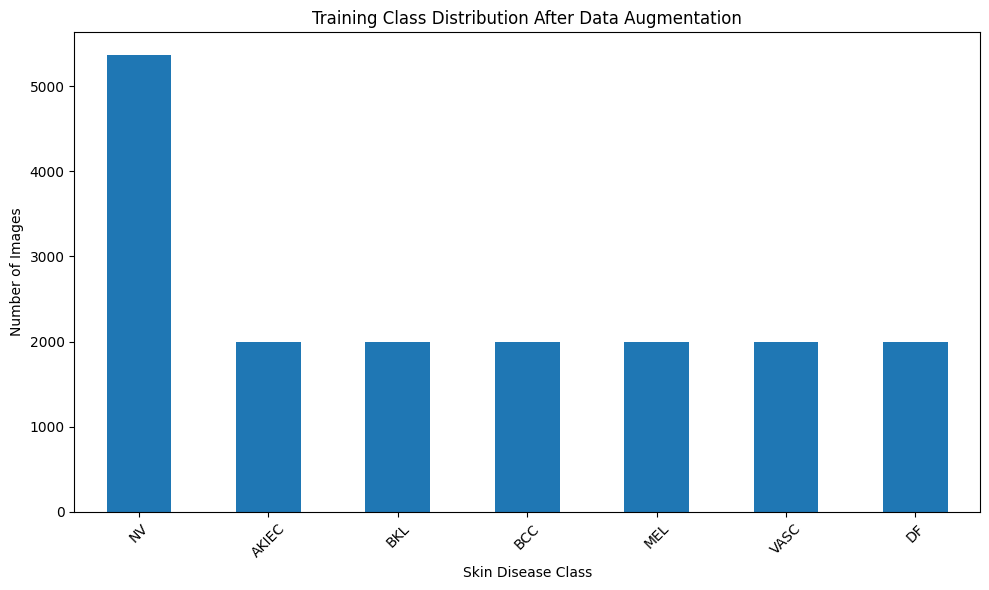

In [39]:
# ============================================================
# CLASS DISTRIBUTION AFTER AUGMENTATION
# ============================================================

plt.figure(figsize=(10, 6))

augmented_train_df["label"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Training Class Distribution After Data Augmentation"
)

plt.xlabel("Skin Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# SAVE AUGMENTED METADATA
# ============================================================

augmented_metadata_path = (
    AUGMENTED_DIR /
    "augmented_train_metadata.csv"
)

augmented_train_df.to_csv(
    augmented_metadata_path,
    index=False
)

print(
    "Augmented metadata saved to:"
)

print(
    augmented_metadata_path
)

Augmented metadata saved to:
/kaggle/working/skinova_augmented/augmented_train_metadata.csv


In [41]:
# ============================================================
# SAVE VALIDATION AND TEST METADATA
# ============================================================

val_df.to_csv(
    AUGMENTED_DIR / "validation_metadata.csv",
    index=False
)

test_df.to_csv(
    AUGMENTED_DIR / "test_metadata.csv",
    index=False
)

print("Validation metadata saved.")
print("Test metadata saved.")

Validation metadata saved.
Test metadata saved.
